# ViZDoom Basic: DQN with AgileRL

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tpoff/rl-epsilon/blob/main/vizdoom-experiments/basic-dqn-AgileRL/AgileRL_DQN_DoomBasic_TrainEval.ipynb)

[![Video about this notebook's results](artifacts/plots_and_figures/video_thumbnail.jpg)](https://www.youtube.com/watch?v=cK0BED0Sp-Y)

We're going to be experimenting with the AgileRL package in this notebook. Specifically, we'll train a vanilla DQN agent to beat the "Basic" scenario in ViZDoom using only visual observations.

AgileRL is a great library for quickly testing RL algorithms and ideas. It's built mainly for population-based training, but it works just as well for a single agent, which is what we'll do here. I prefer it to Stable Baselines3: it's easy to pick up and extend, ships with the common algorithms like PPO, DQN and Rainbow DQN, and in my experience it converges faster. Perfect for quick tests!

Basic is about as simple as Doom gets: one room, one pistol, and one Cacodemon waiting to be shot. That makes it a great first test for an agent learning straight from pixels.

One twist: the agent trains on the stock scenario, but evaluation and recording use a custom version I made, `basic_outro`. It's identical except that the episode doesn't end the instant the Cacodemon dies, so the death animation actually makes it into the videos. This makes it a bit clearer when the agent kills the demon, and makes for a better video to watch!

This notebook walks through setting up the agent, including a nice hack to gather metrics during training, and setting up ViZDoom with either the original Doom WADs or the bundled Freedoom WADs. Then we train the agent and evaluate its performance! Should be fun! If you want to see how it turned out first, I made a [video about the results](https://www.youtube.com/watch?v=cK0BED0Sp-Y). (The video covers a 500k-step run, but this notebook defaults to 50k so it finishes faster. Basic is simple enough that 50k is plenty, but bump `MAX_STEPS` if you want to reproduce the longer run.)

# Setup
First we'll set up our environment and define all the configuration for our experiment.

## Install Dependencies
If we're on Colab we'll need to grab OpenAL first, since ViZDoom needs it to run there, then install everything with pip. I pinned the versions so the notebook doesn't break the next time one of these libraries pushes an update. If you're running locally and already have everything installed, you can skip this cell.

In [1]:
import sys

# test if we're on colab, if we are update some packages
if "google.colab" in sys.modules:
    !apt-get update -qq
    !apt-get install -y -qq libopenal1 libopenal-dev > /dev/null

# install all the python packages we'll need
%pip install -q vizdoom==1.3.1 agilerl==2.8.4 gymnasium==1.3.0 imageio==2.38.0 imageio-ffmpeg==0.6.0 opencv-python==5.0.0.93 scipy==1.17.1 numpy==2.4.6 pandas==3.0.5 torch==2.13.0 matplotlib==3.11.1

Note: you may need to restart the kernel to use updated packages.


## Imports
To make the notebook read a bit nicer we'll go ahead and import everything we'll need in this cell.

In [2]:
import json
import shutil
import subprocess
import sys
from datetime import datetime
from pathlib import Path

import gymnasium
import imageio.v2 as imageio
import imageio_ffmpeg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


from agilerl.algorithms.dqn import DQN
from agilerl.components.replay_buffer import ReplayBuffer
from agilerl.training.train_off_policy import train_off_policy
from gymnasium.spaces import Box
from gymnasium.wrappers import FrameStackObservation, ResizeObservation, TransformObservation, TransformReward
from IPython.display import Video, display
from scipy.io import wavfile


import vizdoom as vzd
from vizdoom import gymnasium_wrapper  # registers the Vizdoom* gymnasium envs
from vizdoom.gymnasium_wrapper.base_gymnasium_env import VizdoomEnv

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration
These are the main knobs for the environment and evaluation. The environment setup is pretty standard for DQN on pixels: the agent picks an action every 4 frames, and it sees the last 4 frames stacked together (shrunk down to 84x84) so it can get a sense of motion. Basic only has 3 buttons, and we only let the agent press one at a time, so it ends up with 4 actions: move left, move right, attack and do nothing.

`EVAL_EPISODES`, `TEST_EPISODES` and `RECORD_EPISODES` control how many episodes we run when scoring each checkpoint, testing the best model and recording videos. `RECORD_CHECKPOINTS` can be set to `"all"` if you want videos of every generation, but heads up, converting them all takes a while!

In [3]:
ENV_NAME = "VizdoomBasic-v1"
NUM_ENVS = 2
FRAME_SKIP = 4
STACK_SIZE = 4
OBS_SIZE = (84, 84)
MAX_BUTTONS_PRESSED = 1

EVAL_EPISODES = 5
TEST_EPISODES = 5
RECORD_EPISODES = 3
RECORD_CHECKPOINTS = "best"  # "best" or "all"

## Files and Paths
All the logic for finding and saving files lives in this section, so the rest of the notebook doesn't have to care where it's running.

### Where We're Running
On Colab, `USE_DRIVE` keeps everything in Google Drive so the results stick around after the session ends, otherwise everything runs out of the notebook's own folder.

In [4]:
USE_DRIVE = True      # Colab only: keep the experiment (and every output) in Google Drive
EXPERIMENT = "basic-dqn-AgileRL"

if "google.colab" in sys.modules and USE_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    experiment_dir = Path("/content/drive/MyDrive/rl-epsilon/vizdoom-experiments") / EXPERIMENT
elif "google.colab" in sys.modules:
    experiment_dir = Path("/content") / EXPERIMENT  # lost when the Colab session ends
else:
    experiment_dir = Path.cwd()  # local: the notebook's own folder
print("experiment:", experiment_dir)

experiment: /Users/coldstart/Desktop/rl-epsilon/vizdoom-experiments/basic-dqn-AgileRL


### Scenario and WAD
By default ViZDoom loads Freedoom assets, which are free replacements for the Doom characters and levels, but it's possible to use the original Doom assets instead by loading the WAD file. If `DOOM2.WAD` is sitting in the `WADS` folder we'll use it, otherwise ViZDoom falls back to Freedoom, which is free to distribute. Same idea for the scenario I made that lets the demon's death animation play before the episode ends: if the custom outro scenario isn't there, we fall back to the stock one.

In [5]:
USE_DOOM2_WAD = True  # use DOOM2.WAD if found, otherwise ViZDoom's bundled Freedoom
SCENARIO = "basic_outro.cfg"   # custom scenario in scenario_files/
STOCK_SCENARIO = "basic.cfg"  # bundled with ViZDoom, used if the custom one is missing

custom_cfg = experiment_dir / "scenario_files" / SCENARIO
scenario_cfg = str(custom_cfg if custom_cfg.is_file() else Path(vzd.scenarios_path) / STOCK_SCENARIO)
SCENARIO_NAME = Path(scenario_cfg).stem

wad = experiment_dir.parent / "WADS" / "DOOM2.WAD"
DOOM_WAD = str(wad) if USE_DOOM2_WAD and wad.is_file() else None
IWAD_NAME = Path(DOOM_WAD).name if DOOM_WAD else "freedoom2"
print("scenario:", scenario_cfg)
print("IWAD:", IWAD_NAME)

scenario: /Users/coldstart/Desktop/rl-epsilon/vizdoom-experiments/basic-dqn-AgileRL/scenario_files/basic_outro.cfg
IWAD: DOOM2.WAD


### Output Folders
Each training run gets its own timestamped folder, and final deliverables (such as the best model, diagrams and episode recordings) end up in `artifacts`. We also name every file we'll save here, so the rest of the notebook can just use them.

In [6]:
run_dir = experiment_dir / "training-runs" / f"run-{datetime.now():%Y%m%d_%H%M%S}"
checkpoint_dir = run_dir / "checkpoints"
recording_dir = run_dir / "recordings"
artifacts_dir = experiment_dir / "artifacts"
model_dir = artifacts_dir / "model"
video_dir = artifacts_dir / "video"
figure_dir = artifacts_dir / "plots_and_figures"
for d in (checkpoint_dir, recording_dir, model_dir, video_dir, figure_dir):
    d.mkdir(parents=True, exist_ok=True)

checkpoint_path = checkpoint_dir / "DQN.pt"
best_model_path = model_dir / "best_model.pt"
metrics_csv = figure_dir / "generation_metrics.csv"
test_runs_csv = figure_dir / "test_runs.csv"
results_path = artifacts_dir / "results.json"
print("run:", run_dir.name)

run: run-20261007_170856


# Environment
Next we'll set up the environment. In Basic, the agent controls Doomguy, armed with a pistol, who can move left, move right and fire. A Cacodemon spawns at a random position on the far wall of a rectangular room, and the goal is to line up and shoot it. The agent only sees the first-person view of the screen. The only positive reward comes from the kill (+106). Every tic alive costs -1 and every missed shot costs -5, so the agent is pushed to aim quickly and not waste ammo.

Most of the code here is turning ViZDoom's raw screen into something our DQN agent can learn from.

## Preprocessing
`preprocess_env` turns the raw screen into what the agent actually sees: grayscale, 84x84, with the last 4 frames stacked together. It also divides the reward by 100, so the kill is worth about 1 instead of 106, which keeps the Q-values in a friendlier range for training.

In [7]:
def preprocess_env(env):
    h, w, _ = env.observation_space["screen"].shape
    env = TransformObservation(
        env,
        lambda obs: (obs["screen"] @ np.array([0.299, 0.587, 0.114])).astype(np.uint8),
        Box(low=0, high=255, shape=(h, w), dtype=np.uint8),
    )
    env = ResizeObservation(env, OBS_SIZE)
    env = FrameStackObservation(env, stack_size=STACK_SIZE)
    return TransformReward(env, lambda r: r / 100.0)

## Creating Environments
`make_env` uses the stock `VizdoomBasic-v1` for training and our scenario file for evaluation and recording.

In [8]:
def make_env(config_file=None):
    """Stock ENV_NAME for training, or scenario_cfg for evaluation and recording."""
    kwargs = dict(
        render_mode="rgb_array",
        frame_skip=FRAME_SKIP,
        screen_resolution=vzd.ScreenResolution.RES_200X125,
        max_buttons_pressed=MAX_BUTTONS_PRESSED,
        treat_episode_timeout_as_truncation=False,
    )
    if DOOM_WAD:
        kwargs["doom_game_path"] = DOOM_WAD
    env = VizdoomEnv(config_file=config_file, **kwargs) if config_file else gymnasium.make(ENV_NAME, **kwargs)
    return preprocess_env(env)

## Training Environments
For training we run `NUM_ENVS` copies of the environment side by side, so the agent collects experience a bit faster.

In [9]:
env = gymnasium.vector.SyncVectorEnv(
    [make_env] * NUM_ENVS, autoreset_mode=gymnasium.vector.AutoresetMode.SAME_STEP
)

objc[36836]: Class SDLApplication is implemented in both /opt/miniconda3/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1562a4a68) and /opt/miniconda3/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x166d38890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[36836]: Class SDLAppDelegate is implemented in both /opt/miniconda3/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1562a4ab8) and /opt/miniconda3/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x166d388e0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[36836]: Class SDLTranslatorResponder is implemented in both /opt/miniconda3/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1562a4b30) and /opt/miniconda3/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x166d38958). This may cause spurio

# Training
Time to actually train the thing!

## Hyperparameters
We train for 50,000 steps across 2 environments. Every 2,000 steps is what AgileRL calls a generation: it evaluates the agent for a few episodes and we save a checkpoint, so we end up with 25 checkpoints to compare later. The agent also waits 1,000 steps before it starts learning, so the replay buffer has something in it first.

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
INIT_HP = {
    "BATCH_SIZE": 64,          # transitions sampled from the replay buffer for each learning update
    "LR": 1e-4,                # learning rate for the optimizer
    "GAMMA": 0.99,             # discount factor, how much future rewards count compared to immediate ones
    "MEMORY_SIZE": 100_000,    # replay buffer size, the oldest experience gets dropped once it's full
    "LEARN_STEP": 4,           # do a learning update every 4 environment steps (counted across all envs)
    "TAU": 0.001,              # how quickly the target network follows the main network (soft update)
    "LEARNING_DELAY": 1000,    # transitions to collect before learning starts, so the buffer isn't empty
    "MAX_STEPS": 50_000,       # total environment steps to train for
    "EVO_STEPS": 2_000,        # steps per generation, AgileRL evaluates the agent after each one
    "EVAL_LOOP": 3,            # episodes per generation evaluation
    "CHECKPOINT": 2_000,       # save a checkpoint every this many steps, one per generation (25 total)
}

## Network
The network is close to the classic DQN layout from the original Atari paper: three convolutional layers followed by a hidden layer, just with a smaller 256 unit hidden layer.

In [11]:
# define our neural network architecture
net_config = {
    "encoder_config": {"channel_size": [32, 64, 64], "kernel_size": [8, 4, 3], "stride_size": [4, 2, 1]},
    "head_config": {"hidden_size": [256], "max_mlp_nodes": 1024},
}

## Replay Buffer and Agent
Now we can create the replay buffer, which holds the agent's past experience so it can learn from it, and the DQN agent itself.

In [12]:
memory = ReplayBuffer(max_size=INIT_HP["MEMORY_SIZE"], device=device)
dqn_agent = DQN(
    observation_space=env.single_observation_space,
    action_space=env.single_action_space,
    net_config=net_config,
    batch_size=INIT_HP["BATCH_SIZE"],
    lr=INIT_HP["LR"],
    learn_step=INIT_HP["LEARN_STEP"],
    gamma=INIT_HP["GAMMA"],
    tau=INIT_HP["TAU"],
    device=device,
)

## Setup Agent to Record Metrics During Eval
Here's the hack I mentioned. AgileRL tracks the loss and the training score, but it clears them right after each evaluation, so there's no easy way to get them back out once training is done. To get around that, we wrap the agent's `test` method so it grabs those metrics right before each evaluation and saves them to `history`. A little hacky, but it works!

In [13]:
history = []
_test = DQN.test.__get__(dqn_agent)


def test_and_log(*args, **kwargs):
    # train_off_policy clears loss and scores right after each evaluation, so read them first.
    m = dqn_agent.metrics
    row = {"steps": m.steps, "loss": m.get_mean("loss"), "train_score": np.mean(m.scores) if m.scores else np.nan}
    row["eval_fitness"] = _test(*args, **kwargs)
    history.append(row)
    return row["eval_fitness"]


dqn_agent.test = test_and_log

## Train
For exploration we start out fully random (epsilon of 1.0) and decay down to 5% random actions as training goes on. On my Mac this takes about 15 minutes.

In [14]:
train_off_policy(
    env=env,
    env_name=ENV_NAME,
    algo="DQN",
    pop=[dqn_agent],
    memory=memory,
    init_hp=INIT_HP,
    max_steps=INIT_HP["MAX_STEPS"],
    evo_steps=INIT_HP["EVO_STEPS"],
    eval_loop=INIT_HP["EVAL_LOOP"],
    learning_delay=INIT_HP["LEARNING_DELAY"],
    checkpoint=INIT_HP["CHECKPOINT"],
    checkpoint_path=str(checkpoint_path),
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.9995,
)
env.close()

Training Progress │   4% │ ▊                    │ 2000/50000 steps │ ⏱️ 00:19 │ ⏳ 07:43 │ 103.63step/s

    Global Steps: 2_000     
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric        ┃  Agent 0 ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ fitness       │  -3.0833 │
├───────────────┼──────────┤
│ score         │  -1.3298 │
│ loss          │   0.0163 │
├───────────────┼──────────┤
│ lr            │ 1.00e-04 │
│ batch_size    │       64 │
│ learn_step    │        4 │
├───────────────┼──────────┤
│ steps         │     2000 │
│ last_mutation │     None │
│ steps/s       │ 103.6311 │
└───────────────┴──────────┘

    Global Steps: 2_000     
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric        ┃  Agent 0 ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ fitness       │  -3.0833 │
├───────────────┼──────────┤
│ score         │  -1.3298 │
│ loss          │   0.0163 │
├───────────────┼──────────┤
│ lr            │ 1.00e-04 │
│ batch_size    │       64 │
│ learn_step    │        4 │
├───────────────┼──────────┤
│ steps         │     2000 │
│ last_mutation │     None │
│ steps/s       │ 103.6311 │
└───────────────┴──────────┘



Training Progress │   8% │ █▌                   │ 4000/50000 steps │ ⏱️ 00:52 │ ⏳ 10:28 │ 73.22step/s 

    Global Steps: 4_000     
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric        ┃  Agent 0 ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ fitness       │  -1.8333 │
├───────────────┼──────────┤
│ score         │  -1.1457 │
│ loss          │ 6.26e-03 │
├───────────────┼──────────┤
│ lr            │ 1.00e-04 │
│ batch_size    │       64 │
│ learn_step    │        4 │
├───────────────┼──────────┤
│ steps         │     4000 │
│ last_mutation │     None │
│ steps/s       │  61.3329 │
└───────────────┴──────────┘

...

    Global Steps: 48_000    
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric        ┃  Agent 0 ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ fitness       │   0.7267 │
├───────────────┼──────────┤
│ score         │   0.6694 │
│ loss          │ 6.70e-03 │
├───────────────┼──────────┤
│ lr            │ 1.00e-04 │
│ batch_size    │       64 │
│ learn_step    │        4 │
├───────────────┼──────────┤
│ steps         │    48000 │
│ last_mutation │     None │
│ steps/s       │  54.8283 │
└───────────────┴──────────┘



Training Progress │ 100% │ ████████████████████ │ 50000/50000 steps │ ⏱️ 14:51 │ ⏳ 00:00 │ 54.13step/s

    Global Steps: 50_000    
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric        ┃  Agent 0 ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ fitness       │   0.6433 │
├───────────────┼──────────┤
│ score         │   0.6769 │
│ loss          │ 6.34e-03 │
├───────────────┼──────────┤
│ lr            │ 1.00e-04 │
│ batch_size    │       64 │
│ learn_step    │        4 │
├───────────────┼──────────┤
│ steps         │    50000 │
│ last_mutation │     None │
│ steps/s       │  54.6214 │
└───────────────┴──────────┘

Training Progress │ 100% │ ████████████████████ │ 50000/50000 steps │ ⏱️ 14:51 │ ⏳ 00:00 │ 56.10step/s

    Global Steps: 50_000    
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric        ┃  Agent 0 ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ fitness       │   0.6433 │
├───────────────┼──────────┤
│ score         │   0.6769 │
│ loss          │ 6.34e-03 │
├───────────────┼──────────┤
│ lr            │ 1.00e-04 │
│ batch_size    │       64 │
│ learn_step    │        4 │
├───────────────┼──────────┤
│ steps         │    50000 │
│ last_mutation │     None │
│ steps/s       │  54.6214 │
└───────────────┴──────────┘



# Evaluation
Training leaves us with a checkpoint for every generation. AgileRL's evaluation scores during training only use a few episodes on the stock scenario, so we'll go back and evaluate every checkpoint ourselves on the outro scenario.

## Evaluation Helpers
A couple of small helpers for the rest of the notebook: `load_agent` loads a saved checkpoint, and `play` runs one episode with it. Since the loaded agent isn't in training mode, it always picks the action it thinks is best, with no random actions.

In [15]:
def load_agent(path):
    agent = DQN.load(str(path), device=device)
    agent.set_training_mode(False)
    return agent


def play(env, agent, obs):
    """Run one greedy episode from `obs`; returns (total_reward, actions)."""
    total, actions, done = 0.0, [], False
    while not done:
        action = int(agent.get_action(obs[None])[0])
        obs, reward, terminated, truncated, _ = env.step(action)
        total += reward
        actions.append(action)
        done = terminated or truncated
    return total, actions

## Find Checkpoints
AgileRL saves each checkpoint with the step count at the end of the file name, so we sort them by that to get them in generation order.

In [16]:
checkpoints = sorted(checkpoint_dir.glob("*.pt"), key=lambda p: int(p.stem.split("_")[-1]))
print(f"found {len(checkpoints)} checkpoints")

found 25 checkpoints


## Evaluate Each Checkpoint
We play `EVAL_EPISODES` episodes with each checkpoint and keep track of the rewards.

In [17]:
eval_env = make_env(scenario_cfg)
eval_rewards = []
for gen, ckpt in enumerate(checkpoints):
    agent = load_agent(ckpt)
    rewards = []
    for episode in range(EVAL_EPISODES):
        obs, _ = eval_env.reset()
        reward, _ = play(eval_env, agent, obs)
        rewards.append(reward)
    eval_rewards.append(rewards)
    print(f"gen {gen:>2}  mean={np.mean(rewards):6.2f}  rewards={np.round(rewards, 2).tolist()}")
eval_env.close()

gen  0  mean= -2.92  rewards=[-3.6, -3.6, -0.22, -3.6, -3.6]
gen  1  mean= -2.30  rewards=[-3.65, -3.7, 0.05, -3.7, -0.48]
gen  2  mean= -2.90  rewards=[-3.55, -3.5, -3.5, -3.5, -0.46]
gen  3  mean= -1.34  rewards=[-0.65, -0.82, -0.86, -3.5, -0.85]
gen  4  mean= -0.89  rewards=[-1.16, -0.08, 0.3, -3.8, 0.3]
gen  5  mean= -1.56  rewards=[-3.5, -3.6, -0.94, 0.15, 0.11]
gen  6  mean= -0.46  rewards=[0.0, 0.26, -1.72, -1.07, 0.21]
gen  7  mean= -2.06  rewards=[-3.5, -3.55, 0.2, -3.5, 0.07]
gen  8  mean=  0.17  rewards=[0.07, 0.35, -0.09, 0.19, 0.35]
gen  9  mean= -0.68  rewards=[-3.55, -0.41, 0.15, 0.15, 0.28]
gen 10  mean= -1.87  rewards=[-3.5, -1.92, -3.5, 0.11, -0.53]
gen 11  mean= -0.00  rewards=[-0.16, 0.17, 0.11, -0.18, 0.04]
gen 12  mean=  0.10  rewards=[0.19, 0.14, -0.15, 0.19, 0.11]
gen 13  mean= -0.03  rewards=[0.07, 0.19, -0.66, 0.07, 0.19]
gen 14  mean=  0.30  rewards=[0.35, 0.07, 0.45, 0.4, 0.24]
gen 15  mean=  0.12  rewards=[-0.07, 0.07, 0.24, 0.16, 0.2]
gen 16  mean=  0.21  

## Best Model
The checkpoint with the best average reward wins (ties go to the later one). We copy it into `artifacts`, and the run summary at the end of the notebook notes which run and generation it came from.

In [18]:
eval_means = [np.mean(r) for r in eval_rewards]
best_gen = 0
for gen, mean in enumerate(eval_means):
    if mean >= eval_means[best_gen]:  # ties go to the later generation
        best_gen = gen
best_checkpoint = checkpoints[best_gen]
print(f"best: gen {best_gen} ({best_checkpoint.name}), mean eval reward {eval_means[best_gen]:.2f}")

best: gen 14 (DQN_0_30000.pt), mean eval reward 0.30


In [19]:
shutil.copy2(best_checkpoint, best_model_path)

PosixPath('/Users/coldstart/Desktop/rl-epsilon/vizdoom-experiments/basic-dqn-AgileRL/artifacts/model/best_model.pt')

## Test the Best Model
Finally we run a few fresh test episodes with the best model, to get a more honest idea of how well it plays.

In [20]:
best_agent = load_agent(best_checkpoint)
test_env = make_env(scenario_cfg)

rows = []
for episode in range(TEST_EPISODES):
    obs, _ = test_env.reset()
    reward, actions = play(test_env, best_agent, obs)
    rows.append({"reward": reward, "length": len(actions), "actions": actions})
test_env.close()
test_runs = pd.DataFrame(rows)
test_runs[["reward", "length"]]

,reward,length
0,-0.12,27
1,0.19,18
2,-0.04,25
3,0.12,21
4,-2.54,88


# Analysis
Let's see how it did! A quick note before we dig in: RL training is pretty noisy, and the evaluation episodes aren't seeded, so your runs may vary. The best generation, the exact rewards and the shape of each curve will shift a bit from run to run, so the comments below focus on the general trends rather than specific numbers.

## Metrics
Here we put everything into one table with a row per generation: the training loss, the training score, AgileRL's evaluation fitness, and our checkpoint evaluation's mean and standard deviation. The table and the test runs both get saved as CSVs in `artifacts`.

In [21]:
metrics = pd.DataFrame(history)
metrics.index.name = "generation"
metrics["ckpt_eval_mean"] = [np.mean(r) for r in eval_rewards]
metrics["ckpt_eval_std"] = [np.std(r) for r in eval_rewards]
metrics

,steps,loss,train_score,eval_fitness,ckpt_eval_mean,ckpt_eval_std
generation,,,,,,
0,2000,0.016306,-1.329778,-3.083333e+00,-2.924,1.352000
1,4000,0.006255,-1.145686,-1.833333e+00,-2.296,1.707473
2,6000,0.005214,-0.757018,-1.856667e+00,-2.902,1.221154
3,8000,0.005094,-1.008679,-9.300000e-01,-1.336,1.084668
4,10000,0.004827,-0.735667,-1.731667e+00,-0.888,1.551082
5,12000,0.006115,-0.672667,-2.530000e+00,-1.556,1.674665
6,14000,0.006003,-0.579153,-6.816667e-01,-0.464,0.792278
7,16000,0.007555,-0.205658,1.700000e-01,-2.056,1.789509
8,18000,0.008190,-0.023820,6.033333e-01,0.174,0.168950


In [22]:
metrics.to_csv(metrics_csv)
test_runs[["reward", "length"]].to_csv(test_runs_csv, index_label="episode")

## Charts
Each chart gets saved to `artifacts/plots_and_figures` as well as shown here.

In [23]:
def save(fig, name):
    fig.savefig(figure_dir / name, dpi=150, bbox_inches="tight")
    plt.show()


gens = metrics.index

### Loss
The loss usually drops quickly at first, then climbs back up for a while once the agent starts landing kills, before slowly settling down. That bump isn't a bad sign. Early on the replay buffer is mostly random flailing with small, predictable rewards, so the targets are easy to fit. Once the agent starts actually killing the Cacodemon, the rewards get bigger and more varied, and the loss goes up with them. With DQN the loss doesn't really tell you how well the agent plays, so the reward charts are what we really care about.

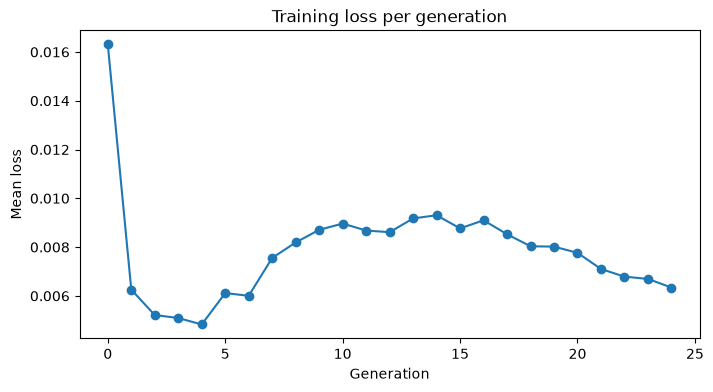

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gens, metrics["loss"], marker="o")
ax.set(xlabel="Generation", ylabel="Mean loss", title="Training loss per generation")
save(fig, "loss.png")

### Average Reward
Both lines should climb over training and level off once the agent reliably kills the demon. The blue line is AgileRL's evaluation during training, and the orange one is our checkpoint evaluation on the outro scenario, with the shaded band showing the standard deviation.

That band tends to be huge early on because episodes basically go one of two ways: the agent kills the Cacodemon for a small positive reward, or it doesn't and times out for a big negative one (around -3 or worse after scaling). A single timeout out of a handful of episodes drags the average way down. As training goes on the band usually shrinks, since the agent kills the demon nearly every time.

The orange line also tends to sit lower than the blue one. That's most likely because the outro keeps the episode running for an extra 50 tics after the kill, and every tic costs a little reward, so it's best to compare checkpoints within the same line rather than across them.

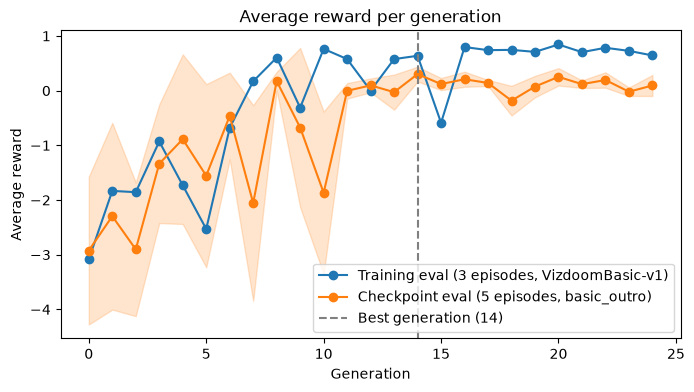

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gens, metrics["eval_fitness"], marker="o", label=f"Training eval ({INIT_HP['EVAL_LOOP']} episodes, {ENV_NAME})")
(line,) = ax.plot(gens, metrics["ckpt_eval_mean"], marker="o", label=f"Checkpoint eval ({EVAL_EPISODES} episodes, {SCENARIO_NAME})")
ax.fill_between(gens, metrics["ckpt_eval_mean"] - metrics["ckpt_eval_std"],
                metrics["ckpt_eval_mean"] + metrics["ckpt_eval_std"], color=line.get_color(), alpha=0.2)
ax.axvline(best_gen, color="gray", linestyle="--", label=f"Best generation ({best_gen})")
ax.set(xlabel="Generation", ylabel="Average reward", title="Average reward per generation")
ax.legend()
save(fig, "average_reward.png")

### Training Score
This is the average score of the training episodes in each generation, random exploration actions included. It usually climbs steadily as epsilon decays and the agent gets better. It's typically the smoothest curve of the bunch, since each point averages over a lot more episodes than the evaluations do.

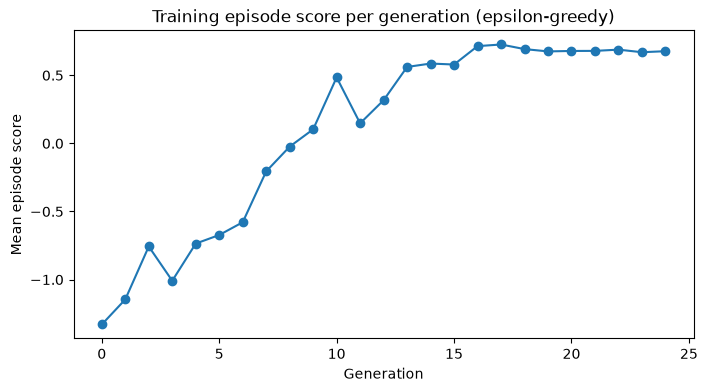

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gens, metrics["train_score"], marker="o")
ax.set(xlabel="Generation", ylabel="Mean episode score", title="Training episode score per generation (epsilon-greedy)")
save(fig, "training_score.png")

### Test Runs
A well trained agent should kill the Cacodemon in every test episode, and fairly quickly. Long episodes are usually ones where it lost track of the demon or ran out the clock. Don't be surprised if the average test reward comes out a bit lower than the best checkpoint's evaluation score. We picked the best checkpoint based on only a few episodes each, so some of its score was probably just luck, and the fresh test runs give a more honest number.

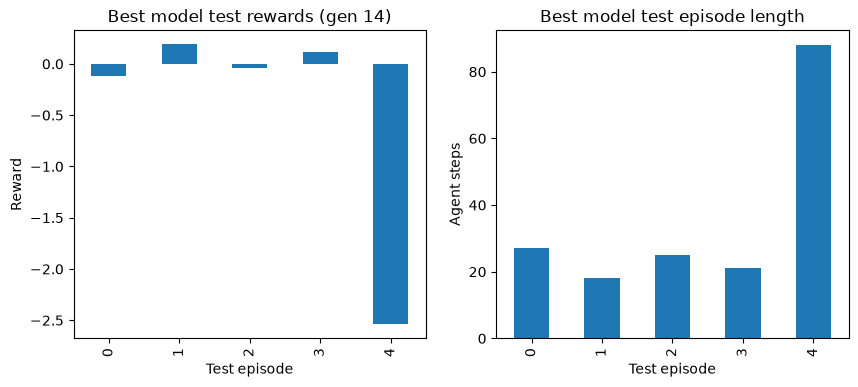

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
test_runs["reward"].plot.bar(ax=ax1, xlabel="Test episode", ylabel="Reward", title=f"Best model test rewards (gen {best_gen})")
test_runs["length"].plot.bar(ax=ax2, xlabel="Test episode", ylabel="Agent steps", title="Best model test episode length")
save(fig, "test_runs.png")

### Action Distribution
First we give each action a readable name, like `MOVE_LEFT` or `NOOP`, using the button combinations ViZDoom assigned to each action.

In [28]:
names_env = make_env(scenario_cfg)
buttons = [b.name for b in names_env.unwrapped.game.get_available_buttons()]
action_names = []
for combo in names_env.unwrapped.button_map:
    pressed = [button for button, on in zip(buttons, combo) if on]
    action_names.append("+".join(pressed) if pressed else "NOOP")
names_env.close()
action_names

['NOOP', 'ATTACK', 'MOVE_RIGHT', 'MOVE_LEFT']

The best agent mostly alternates between moving toward the demon and shooting. You'll often see one direction favored over the other, which could be a habit the agent picked up or just the small sample from a few test episodes. A good chunk of "do nothing" steps is normal too. Some of those come from the outro after the kill, and some from the agent waiting for its momentum to die down, since in Doom you don't stop right away after letting go of a movement key.

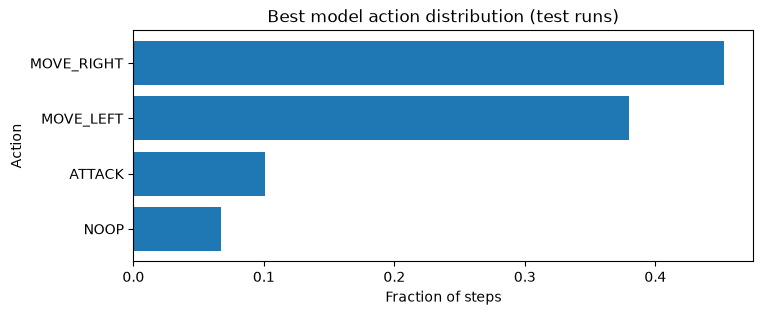

In [29]:
all_actions = np.concatenate(test_runs["actions"].to_list())
freq = pd.Series([action_names[a] for a in all_actions]).value_counts(normalize=True, ascending=True)
fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(freq))))
ax.barh(freq.index, freq.values)
ax.set(xlabel="Fraction of steps", ylabel="Action", title="Best model action distribution (test runs)")
save(fig, "test_action_distribution.png")

# Recording
Finally, let's get some video of the agent in action! This is the most involved part of the notebook, since we record ViZDoom's own demo files and then replay them at a much higher resolution.

## Recording Helpers
ViZDoom can record an episode to a `.lmp` demo file, which only stores the player's inputs, so it's tiny. The catch is that the Gymnasium wrapper doesn't expose this, so `reset_with_lmp` temporarily swaps out the environment's reset so it starts a recorded episode instead. The demo only gets written once the next episode starts, which is what `flush_lmp` is for.

In [30]:
def reset_with_lmp(env, lmp_path):
    base = env.unwrapped
    orig_reset = base.reset

    def recorded_reset(*, seed=None, options=None):
        gymnasium.Env.reset(base, seed=seed)
        game_seed = int(
            base.np_random.integers(0, np.iinfo(np.uint32).max + 1, dtype=np.uint32)
        )
        base.game.set_seed(game_seed)
        if not base.game.is_running():
            base.game.init()
        base.game.new_episode(str(lmp_path))
        base.state = base.game.get_state()
        return base._VizdoomEnv__collect_observations(), {}

    base.reset = recorded_reset
    try:
        return env.reset()
    finally:
        base.reset = orig_reset


def flush_lmp(env):
    env.unwrapped.game.new_episode()

## Record Checkpoints
Here we play `RECORD_EPISODES` episodes with the best checkpoint (or every checkpoint, if `RECORD_CHECKPOINTS` is `"all"`) and record each one. Videos of the best model go into `artifacts/video`, and anything else stays in the run's `recordings` folder. Old videos of the best model get cleared out first, so they don't get mixed up with this run's.

In [31]:
assert RECORD_CHECKPOINTS in ("best", "all")
record_checkpoints = [best_checkpoint] if RECORD_CHECKPOINTS == "best" else checkpoints

for old in video_dir.glob("best_episode_*"):
    old.unlink()

In [32]:
record_env = make_env(scenario_cfg)
lmps = []
for ckpt in record_checkpoints:
    gen = checkpoints.index(ckpt)
    out_dir, prefix = (video_dir, "best") if ckpt == best_checkpoint else (recording_dir, f"gen_{gen}")
    agent = load_agent(ckpt)
    for episode in range(RECORD_EPISODES):
        lmp = out_dir / f"{prefix}_episode_{episode}.lmp"
        obs, _ = reset_with_lmp(record_env, lmp)
        reward, _ = play(record_env, agent, obs)
        print(f"gen {gen:>2}  episode {episode}  reward={reward:.2f}  -> {lmp.name}")
        lmps.append(lmp)
flush_lmp(record_env)
record_env.close()

gen 14  episode 0  reward=0.35  -> best_episode_0.lmp
gen 14  episode 1  reward=-0.41  -> best_episode_1.lmp
gen 14  episode 2  reward=-0.00  -> best_episode_2.lmp


## Convert to MP4
`lmp_to_mp4` then replays the demo in a separate game at 1080p with the HUD on, grabs every frame (and the audio, when there is any) and saves it as an MP4. Since we're replaying the inputs rather than saving what the agent saw, the video looks a lot better than the 84x84 grayscale the agent trained on! On my Mac the audio comes out silent, so those videos don't have sound.

Each demo takes a few seconds to convert.

In [33]:
SAMPLE_RATE = 22050


def lmp_to_mp4(lmp_path):
    """Replay an .lmp at 1080p with HUD and audio, and write it next to the .lmp as .mp4."""
    lmp_path = Path(lmp_path)
    mp4_path = lmp_path.with_suffix(".mp4")
    silent_path = lmp_path.with_name(lmp_path.stem + "_silent.mp4")
    wav_path = lmp_path.with_suffix(".wav")

    game = vzd.DoomGame()
    game.load_config(scenario_cfg)
    if DOOM_WAD:
        game.set_doom_game_path(DOOM_WAD)
    game.set_screen_resolution(vzd.ScreenResolution.RES_1920X1080)
    game.set_render_hud(True)
    game.set_render_corpses(True)
    game.set_window_visible(False)
    game.set_audio_buffer_enabled(True)
    game.set_audio_sampling_rate(vzd.SamplingRate.SR_22050)
    game.set_audio_buffer_size(1)
    game.add_game_args("+snd_efx 0")
    game.set_mode(vzd.Mode.SPECTATOR)
    game.init()

    frames, audio = [], []
    try:
        game.replay_episode(str(lmp_path))
        while not game.is_episode_finished():
            state = game.get_state()
            if state is not None:
                frames.append(np.transpose(state.screen_buffer, (1, 2, 0)))
                if state.audio_buffer is not None:
                    audio.append(state.audio_buffer)
            game.advance_action()
    finally:
        game.close()

    imageio.mimsave(silent_path, frames, fps=35, codec="libx264", quality=8)

    audio = np.concatenate(audio) if audio else np.zeros(1)
    if not audio.any():  # no sound captured (e.g. on macOS): keep the silent video
        silent_path.replace(mp4_path)
        return mp4_path

    wavfile.write(wav_path, SAMPLE_RATE, audio)
    subprocess.run(
        [imageio_ffmpeg.get_ffmpeg_exe(), "-y", "-i", silent_path, "-i", wav_path,
         "-c:v", "copy", "-c:a", "aac", "-shortest", mp4_path],
        check=True, capture_output=True,
    )
    silent_path.unlink()
    wav_path.unlink()
    return mp4_path

In [34]:
mp4s = [lmp_to_mp4(lmp) for lmp in lmps]
mp4s

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 1080) to (1920, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 1080) to (1920, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 1080) to (1920, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


[PosixPath('/Users/coldstart/Desktop/rl-epsilon/vizdoom-experiments/basic-dqn-AgileRL/artifacts/video/best_episode_0.mp4'),
 PosixPath('/Users/coldstart/Desktop/rl-epsilon/vizdoom-experiments/basic-dqn-AgileRL/artifacts/video/best_episode_1.mp4'),
 PosixPath('/Users/coldstart/Desktop/rl-epsilon/vizdoom-experiments/basic-dqn-AgileRL/artifacts/video/best_episode_2.mp4')]

## Preview
And here's the best agent in action!

In [35]:
display(Video(str(next(m for m in mp4s if m.name.startswith("best"))), embed=True, width=480))

# Results
Here's a summary of the run, which also gets saved to `artifacts/results.json` so it's easy to compare runs later.

In [36]:
results = {
    "run": run_dir.name,
    "scenario": SCENARIO_NAME,
    "iwad": IWAD_NAME,
    "best_checkpoint": best_checkpoint.name,
    "best_generation": best_gen,
    "best_steps": int(metrics.loc[best_gen, "steps"]),
    "generations": len(checkpoints),
    "checkpoint_eval_mean": round(float(metrics.loc[best_gen, "ckpt_eval_mean"]), 4),
    "checkpoint_eval_std": round(float(metrics.loc[best_gen, "ckpt_eval_std"]), 4),
    "checkpoint_eval_rewards": [round(float(r), 4) for r in eval_rewards[best_gen]],
    "test_episodes": len(test_runs),
    "test_reward_mean": round(float(test_runs["reward"].mean()), 4),
    "test_reward_std": round(float(test_runs["reward"].std(ddof=0)), 4),
    "test_reward_min": round(float(test_runs["reward"].min()), 4),
    "test_reward_max": round(float(test_runs["reward"].max()), 4),
    "test_length_mean": round(float(test_runs["length"].mean()), 4),
    "best_video": [str(m.relative_to(experiment_dir)) for m in mp4s if m.name.startswith("best")],
}
results_path.write_text(json.dumps(results, indent=2))
pd.Series(results, name="value").to_frame()

,value
run,run-20261007_170856
scenario,basic_outro
iwad,DOOM2.WAD
best_checkpoint,DQN_0_30000.pt
best_generation,14
best_steps,30000
generations,25
checkpoint_eval_mean,0.302
checkpoint_eval_std,0.1353
checkpoint_eval_rewards,"[0.35, 0.07, 0.45, 0.4, 0.24]"


# Wrapping Up
And that's it! With just a vanilla DQN and 50k steps, the agent goes from flailing around randomly to lining up and shooting the Cacodemon almost every time. Not bad for learning straight from pixels!

Basic is a pretty easy scenario though, so the next step is something harder. There are a lot of built in environments included in ViZDoom which are much more challenging and I invite you to take on a few. I'll be working on them myself and hope to share the results and notebooks for those experiments soon! Thanks for reading!